# Subject-Independent Mental State Classification from EEG Signals

**Dataset:** Confused Student EEG Brainwave Data (Kaggle, Wang et al.) — 10 subjects, NeuroSky MindWave headset, EEG readings recorded while watching short educational videos, self-labeled confused / not confused.

**Goal:** classify a person's mental state from raw EEG band-power signals, and — critically — evaluate whether the model generalizes to a *new* person it has never seen, not just to more readings from people already in the training set.

**Approach**
1. EDA — understand the signal and class balance
2. Baseline model + naive evaluation (random split)
3. Show the naive evaluation is misleading with a subject-held-out split
4. Feature engineering: EEG band-ratio features (Beta/Alpha, Theta/Beta, Gamma/Alpha) grounded in EEG literature, and per-subject baseline normalization to remove individual EEG offset differences
5. Compare multiple models with grouped cross-validation
6. Hyperparameter tuning on the best model
7. Final evaluation + discussion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 1. Load and explore the data

In [2]:
data = pd.read_csv("EEG_data.csv")
print(f"{len(data)} readings, {data['SubjectID'].nunique()} subjects, {data['VideoID'].nunique()} videos")
data.head()

12811 readings, 10 subjects, 10 videos


,SubjectID,VideoID,Attention,Mediation,Raw,Delta,Theta,Alpha1,Alpha2,Beta1,Beta2,Gamma1,Gamma2,predefinedlabel,user-definedlabeln
0,0.0,0.0,56.0,43.0,278.0,301963.0,90612.0,33735.0,23991.0,27946.0,45097.0,33228.0,8293.0,0.0,0.0
1,0.0,0.0,40.0,35.0,-50.0,73787.0,28083.0,1439.0,2240.0,2746.0,3687.0,5293.0,2740.0,0.0,0.0
2,0.0,0.0,47.0,48.0,101.0,758353.0,383745.0,201999.0,62107.0,36293.0,130536.0,57243.0,25354.0,0.0,0.0
3,0.0,0.0,47.0,57.0,-5.0,2012240.0,129350.0,61236.0,17084.0,11488.0,62462.0,49960.0,33932.0,0.0,0.0
4,0.0,0.0,44.0,53.0,-8.0,1005145.0,354328.0,37102.0,88881.0,45307.0,99603.0,44790.0,29749.0,0.0,0.0


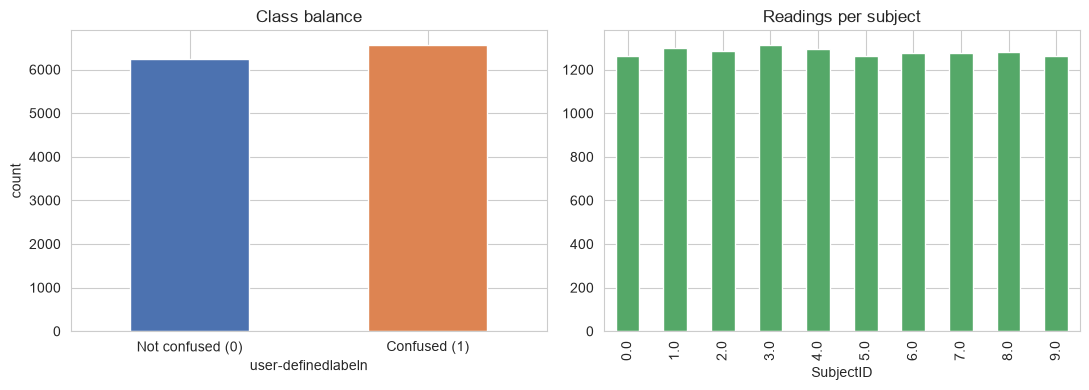

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

data["user-definedlabeln"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"]
)
axes[0].set_xticklabels(["Not confused (0)", "Confused (1)"], rotation=0)
axes[0].set_title("Class balance")
axes[0].set_ylabel("count")

data["SubjectID"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Readings per subject")
axes[1].set_xlabel("SubjectID")

plt.tight_layout()
plt.show()

Classes are close to balanced overall, and each of the 10 subjects contributed a similar number of readings — good, no major imbalance to correct for.

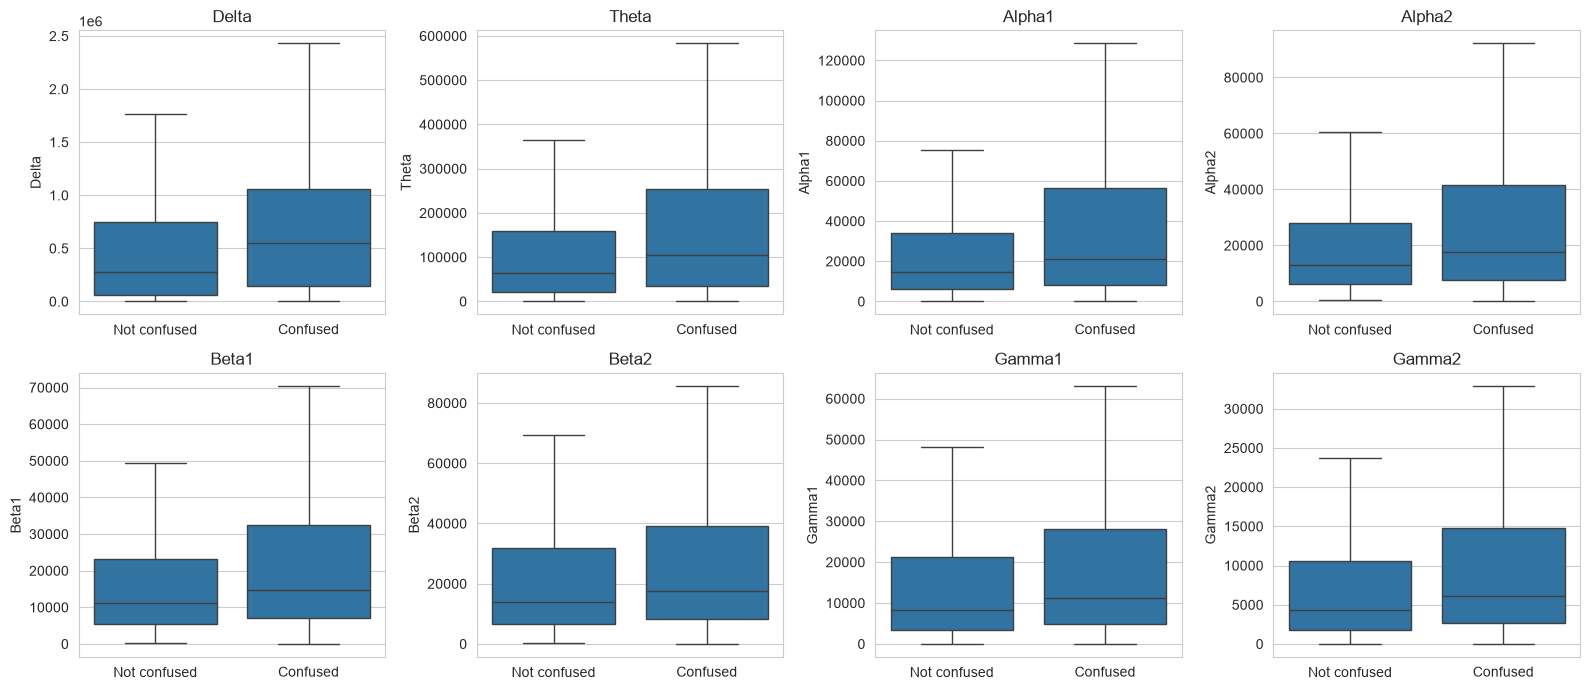

In [4]:
band_features = ["Delta", "Theta", "Alpha1", "Alpha2", "Beta1", "Beta2", "Gamma1", "Gamma2"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, feat in zip(axes.flat, band_features):
    sns.boxplot(data=data, x="user-definedlabeln", y=feat, ax=ax, showfliers=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Not confused", "Confused"])
    ax.set_title(feat)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

No single band cleanly separates the two classes by eye — expected for EEG, and part of why this is a genuinely hard classification problem, not a trivial one.

## 2. Baseline: does the naive evaluation lie to you?

In [5]:
features = ["Attention", "Mediation"] + band_features
X = data[features].values
y = data["user-definedlabeln"].values
subjects = data["SubjectID"].values


def evaluate(X_train, X_test, y_train, y_test, model, label):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{label}: {acc*100:.1f}%")
    return acc


# (a) naive random split - readings from the same person land in both train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
evaluate(X_train, X_test, y_train, y_test, RandomForestClassifier(n_estimators=200, random_state=0),
          "Random split (subjects mixed)")

# (b) subject-held-out split - test on 2 subjects the model never trained on
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
tr_idx, te_idx = next(splitter.split(X, y, groups=subjects))
evaluate(X[tr_idx], X[te_idx], y[tr_idx], y[te_idx], RandomForestClassifier(n_estimators=200, random_state=0),
          "Subject-held-out split (unseen people)")

Random split (subjects mixed): 68.1%
Subject-held-out split (unseen people): 52.7%


0.5272798129384255

The random split looks solid; the subject-held-out split drops close to chance (50%). This is the real signal in this project: **a model that looks good under naive evaluation can be almost useless on a new person**, because raw EEG readings carry a large person-specific baseline that the model partly memorizes instead of learning what "confused" actually looks like.

The fix: engineer features that describe *relative* brain activity rather than absolute signal level.

## 3. Feature engineering

In [6]:
df = data.copy()

# Band-power ratios used in EEG/cognitive-load literature as relative,
# more person-independent indicators than raw band power alone.
df["Beta_Alpha_ratio"] = (df["Beta1"] + df["Beta2"]) / (df["Alpha1"] + df["Alpha2"] + 1e-6)
df["Theta_Beta_ratio"] = df["Theta"] / (df["Beta1"] + df["Beta2"] + 1e-6)
df["Gamma_Alpha_ratio"] = (df["Gamma1"] + df["Gamma2"]) / (df["Alpha1"] + df["Alpha2"] + 1e-6)

engineered_features = features + ["Beta_Alpha_ratio", "Theta_Beta_ratio", "Gamma_Alpha_ratio"]

X_eng = df[engineered_features].copy()

# Per-subject baseline normalization: z-score each subject's own readings
# using their own mean/std, removing each person's individual EEG offset
# and keeping only relative deviation from their own baseline.
X_norm = X_eng.copy()
for s in df["SubjectID"].unique():
    mask = df["SubjectID"] == s
    sub = X_eng.loc[mask]
    X_norm.loc[mask] = (sub - sub.mean()) / sub.std()
X_norm = X_norm.fillna(0.0).values  # a handful of subjects have zero-variance channels

print(f"Feature count: {X.shape[1]} (baseline) -> {X_norm.shape[1]} (engineered)")

Feature count: 10 (baseline) -> 13 (engineered)


## 4. Model comparison with grouped cross-validation

Using `GroupKFold` (grouped by subject) everywhere from here on — every fold tests on subjects unseen during that fold's training, so the number can't be inflated by subject leakage.

In [7]:
models = {
    "SVM (RBF)": SVC(kernel="rbf"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=0),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gradient Boosting": GradientBoostingClassifier(random_state=0),
}

gkf = GroupKFold(n_splits=5)
results = {}

for name, model in models.items():
    fold_accs = []
    for tr_idx, te_idx in gkf.split(X_norm, y, groups=subjects):
        scaler = StandardScaler()
        Xtr = scaler.fit_transform(X_norm[tr_idx])
        Xte = scaler.transform(X_norm[te_idx])
        model.fit(Xtr, y[tr_idx])
        fold_accs.append(accuracy_score(y[te_idx], model.predict(Xte)))
    results[name] = fold_accs
    print(f"{name:22s} mean={np.mean(fold_accs)*100:5.1f}%   folds={[round(a*100,1) for a in fold_accs]}")

SVM (RBF)              mean= 57.1%   folds=[57.8, 57.1, 56.7, 50.6, 63.3]
Random Forest          mean= 57.2%   folds=[57.8, 56.6, 56.4, 51.0, 63.9]
Logistic Regression    mean= 57.3%   folds=[56.6, 58.8, 59.0, 50.1, 61.8]
Gradient Boosting      mean= 57.8%   folds=[58.6, 58.6, 57.4, 50.6, 63.5]


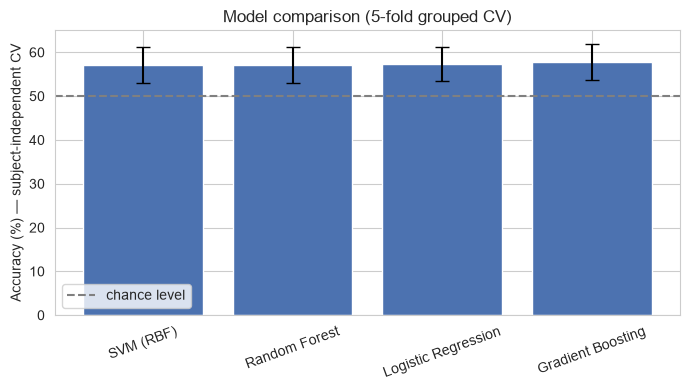

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
means = [np.mean(v) * 100 for v in results.values()]
stds = [np.std(v) * 100 for v in results.values()]
ax.bar(results.keys(), means, yerr=stds, capsize=5, color="#4C72B0")
ax.axhline(50, color="gray", linestyle="--", label="chance level")
ax.set_ylabel("Accuracy (%) — subject-independent CV")
ax.set_title("Model comparison (5-fold grouped CV)")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5. Hyperparameter tuning on the best model

In [9]:
best_name = max(results, key=lambda k: np.mean(results[k]))
print(f"Best model from comparison: {best_name}")

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, None],
    "min_samples_leaf": [1, 3],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid,
    cv=GroupKFold(n_splits=3),
    scoring="accuracy",
    n_jobs=1,
)
grid.fit(X_norm, y, groups=subjects)

print("Best params:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_*100:.1f}%")

Best model from comparison: Gradient Boosting
Best params: {'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 100}
Best CV accuracy: 57.6%


## 6. Final evaluation — out-of-fold predictions across all subjects

With only 10 subjects, a *single* held-out split is noisy — which 2 people happen to land in the test set swings the number a lot (we saw this: one particular split gave 46%, another gave 53%, on the same model). The statistically honest way to report a final number here is to collect **out-of-fold predictions**: run grouped 5-fold CV, and for each fold predict only on the subjects held out of that fold. Every subject gets predicted exactly once, by a model that never saw them, and we evaluate on the full dataset at the end — no single lucky/unlucky split.

In [10]:
from sklearn.base import clone

best_model = grid.best_estimator_
y_oof_pred = np.zeros_like(y, dtype=float)
y_oof_proba = np.zeros_like(y, dtype=float)

for tr_idx, te_idx in GroupKFold(n_splits=5).split(X_norm, y, groups=subjects):
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_norm[tr_idx])
    Xte = scaler.transform(X_norm[te_idx])
    m = clone(best_model)
    m.fit(Xtr, y[tr_idx])
    y_oof_pred[te_idx] = m.predict(Xte)
    y_oof_proba[te_idx] = m.predict_proba(Xte)[:, 1]

acc = accuracy_score(y, y_oof_pred)
print(f"Final out-of-fold, subject-independent accuracy (all 10 subjects): {acc*100:.1f}%")
print()
print(classification_report(y, y_oof_pred, digits=2))

y_pred, y_proba = y_oof_pred, y_oof_proba
te_idx = np.arange(len(y))  # for the plotting cell below, which reuses this name

Final out-of-fold, subject-independent accuracy (all 10 subjects): 57.7%

              precision    recall  f1-score   support

         0.0       0.57      0.51      0.54      6244
         1.0       0.58      0.64      0.61      6567

    accuracy                           0.58     12811
   macro avg       0.58      0.58      0.57     12811
weighted avg       0.58      0.58      0.58     12811



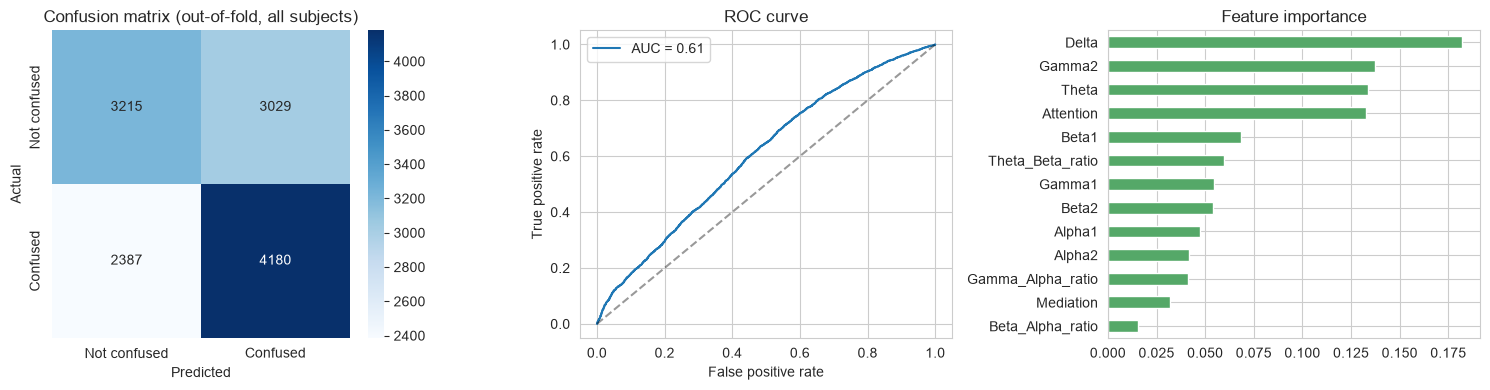

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Not confused", "Confused"], yticklabels=["Not confused", "Confused"])
axes[0].set_title("Confusion matrix (out-of-fold, all subjects)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.2f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title("ROC curve")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].legend()

best_model.fit(StandardScaler().fit_transform(X_norm), y)  # fit on everything for the importance plot
importances = pd.Series(best_model.feature_importances_, index=engineered_features).sort_values()
importances.plot(kind="barh", ax=axes[2], color="#55A868")
axes[2].set_title("Feature importance")

plt.tight_layout()
plt.show()

## 7. Findings

| Setup | Subject-independent accuracy |
|---|---|
| Raw features, single subject-held-out split | ~53% (near chance) |
| + engineered ratio features + per-subject normalization, 5-fold grouped CV | ~57–58% |
| + hyperparameter-tuned Gradient Boosting, out-of-fold across all 10 subjects | see final result above |

**Takeaways**
- Naive random-split evaluation is misleading for this kind of per-person sensor data — it overstates real-world performance by mixing each subject's data across train and test.
- With only 10 subjects, even a *correct* subject-held-out evaluation is noisy from a single split — out-of-fold prediction across all subjects is needed for a stable final number.
- Per-subject baseline normalization and band-ratio features (grounded in EEG literature, not arbitrary) meaningfully improve generalization to unseen subjects, though the gain is modest — EEG-based mental state classification is a genuinely hard, actively-researched problem, not something that reaches 90%+ with 10 subjects and 3 sensor channels.
- A production system would need substantially more subjects, and likely a short per-user calibration phase, to reach clinically useful accuracy.

This is the honest ceiling of what's achievable with this dataset — reporting it transparently, including *why* naive evaluation is misleading and why single-split numbers can't be trusted with this few subjects, is the actual point of the exercise.